In [ ]:
from pathlib import Path

import pandas as pd
from crystal_ball_utils import Generator, plot
from IPython.utils import io
from torch import zeros_like

# Imposter game setup

In [2]:
with io.capture_output():

    root = Path("../logs/TRB/cvae_foundation/conditioned/version_0")
    ckpt_path = root / "checkpoints/epoch=91-step=14444.ckpt"
    schedule_encoder_path = root / "schedule_encoder.pkl"
    attributes_encoder_path = root / "attribute_encoder.pkl"

    real_schedules_path = Path("../tmp/nts_schedules_2019_2023_200.csv")
    real_schedules = pd.read_csv(real_schedules_path)
    real_labels_path = Path("../tmp/nts_attributes_2019_2023_200.csv")
    real_labels = pd.read_csv(real_labels_path)

    crystal_ball = Generator(
        model_name="CVAEContLSTM",
        ckpt_path=ckpt_path,
        schedule_encoder_path=schedule_encoder_path,
        attributes_encoder_path=attributes_encoder_path,
    )

real_labels.head()

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


,pid,age,gender,ethnicity,education,license,car_access,work_status,mobility,wheelchair_user,...,income,hh_size,hh_composition,hh_children,hh_cars,hh_bikes,hh_motorcycles,blue_badge,num_license_holders,age_group
0,0,3,M,non-white,unknown,unknown,yes,unemployed,unknown,unknown,...,5,4,2adult_1+child,2,2,1,0,yes,2,<5
1,1,3,M,non-white,unknown,unknown,yes,unemployed,unknown,unknown,...,5,4,2adult_1+child,2,2,1,0,yes,2,<5
2,3,30,M,non-white,Y,yes,yes,employed,none,unknown,...,5,4,2adult_1+child,2,2,1,0,yes,2,30-40
3,5,3,M,non-white,unknown,unknown,yes,unemployed,unknown,unknown,...,5,4,2adult_1+child,2,2,1,0,yes,2,<5
4,6,3,M,non-white,unknown,unknown,yes,unemployed,unknown,unknown,...,5,4,2adult_1+child,2,2,1,0,yes,2,<5


In [3]:
my_labels = {
    "gender": "M",  # M or F
    "age_group": "30-40",  # <5, 5-11, 11-16, 16-20, 20-30, 30-40, 40-50, 50-70, 70+
    "car_access": "no",  # yes or no
    "work_status": "employed",  # employed, unemployed, student
    "income": 3,  # 1, 2, 3, 4, 5
    "year": 2023,  # 2019, 2020, 2021, 2022, 2023
}

labels = pd.DataFrame([my_labels])
labels["pid"] = 0

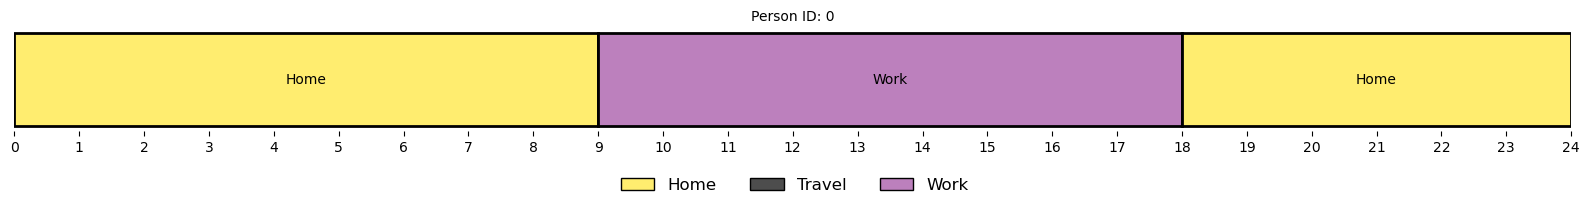

In [4]:
my_schedule = {
    "act": [
        "home",
        "work",
        "home",
    ],  # activities: home, work, shop, education, other, visit, escort, medical
    "duration": [9, 9, 6],
}

schedule = pd.DataFrame(my_schedule)
schedule.duration = schedule.duration * 60  # convert hours to minutes
schedule.duration = (
    1440 * schedule.duration / schedule.duration.sum()
)  # normalize by total minutes in a day
schedule["end"] = schedule.duration.cumsum()
schedule["start"] = schedule["end"].shift(1).fillna(0)
schedule["pid"] = 0  # dummy

plot(schedule)

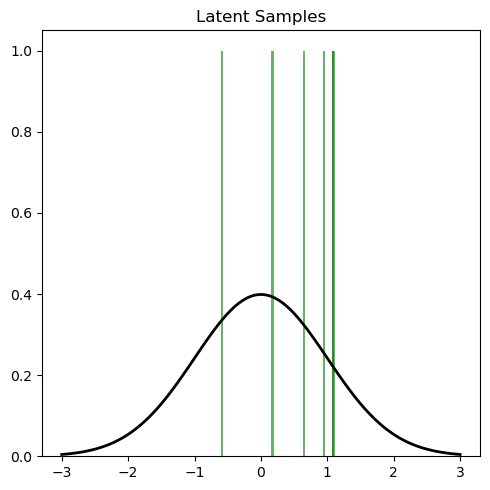

In [5]:
crystal_ball.embed(schedule, labels)

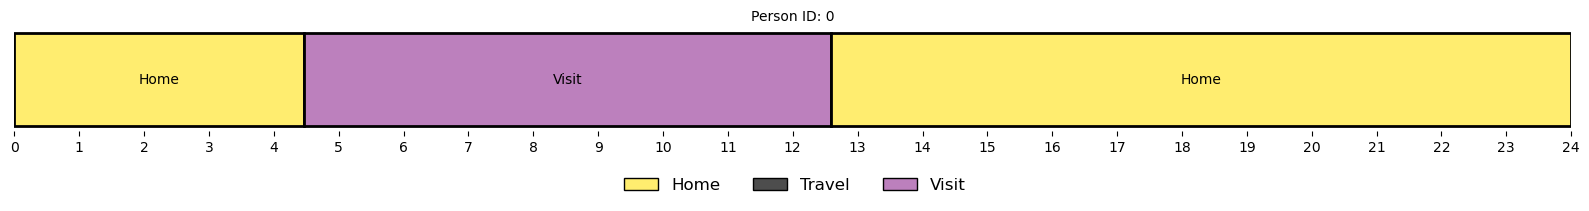

In [6]:
crystal_ball.z = zeros_like(crystal_ball.z)
plot(crystal_ball(labels))

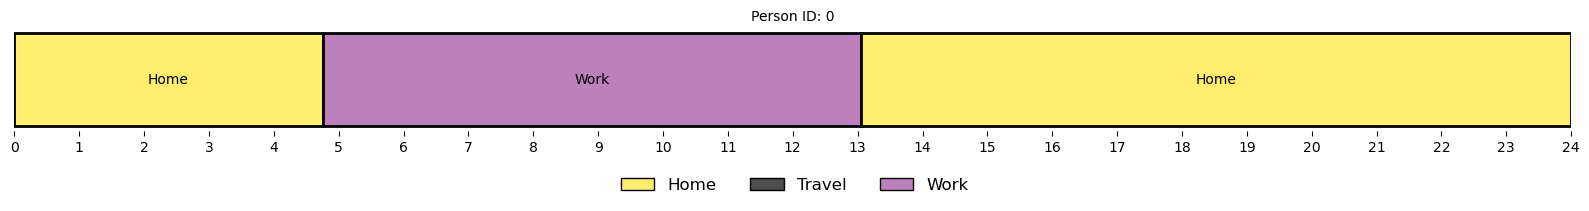

In [7]:
my_labels = {
    "gender": "M",  # M or F
    "age_group": "50-70",  # <5, 5-11, 11-16, 16-20, 20-30, 30-40, 40-50, 50-70, 70+
    "car_access": "yes",  # yes or no
    "work_status": "employed",  # employed, unemployed, student
    "income": 4,  # 1, 2, 3, 4, 5
    "year": 2023,  # 2019, 2020, 2021, 2022, 2023
}

labels = pd.DataFrame([my_labels])
labels["pid"] = 0
plot(crystal_ball(labels))